EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn

In [2]:
df = pd.read_csv("../data/RTA Dataset.csv")

In [3]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [4]:
df.shape

(12316, 32)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

In [6]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [7]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
for column in df.columns:
    print(column)
    print(df[column].unique())
    print("="*50)

Time
<ArrowStringArray>
['17:02:00',  '1:06:00', '14:15:00', '17:30:00', '17:20:00', '14:40:00',
 '17:45:00', '22:45:00',  '8:20:00', '15:10:00',
 ...
 '23:55:00', '15:58:00', '10:26:00',  '5:53:00',  '8:34:00', '22:11:00',
  '7:02:00',  '7:24:00', '19:18:00',  '2:47:00']
Length: 1074, dtype: str
Day_of_week
<ArrowStringArray>
['Monday', 'Sunday', 'Friday', 'Wednesday', 'Saturday', 'Thursday', 'Tuesday']
Length: 7, dtype: str
Age_band_of_driver
<ArrowStringArray>
['18-30', '31-50', 'Under 18', 'Over 51', 'Unknown']
Length: 5, dtype: str
Sex_of_driver
<ArrowStringArray>
['Male', 'Female', 'Unknown']
Length: 3, dtype: str
Educational_level
<ArrowStringArray>
[ 'Above high school', 'Junior high school',                  nan,
  'Elementary school',        'High school',            'Unknown',
         'Illiterate',  'Writing & reading']
Length: 8, dtype: str
Vehicle_driver_relation
<ArrowStringArray>
['Employee', 'Unknown', 'Owner', nan, 'Other']
Length: 5, dtype: str
Driving_experience
<Ar

In [10]:
df["Accident_severity"].value_counts()

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Visualization

C:\Users\hp\AppData\Local\Temp\ipykernel_18612\2176355229.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


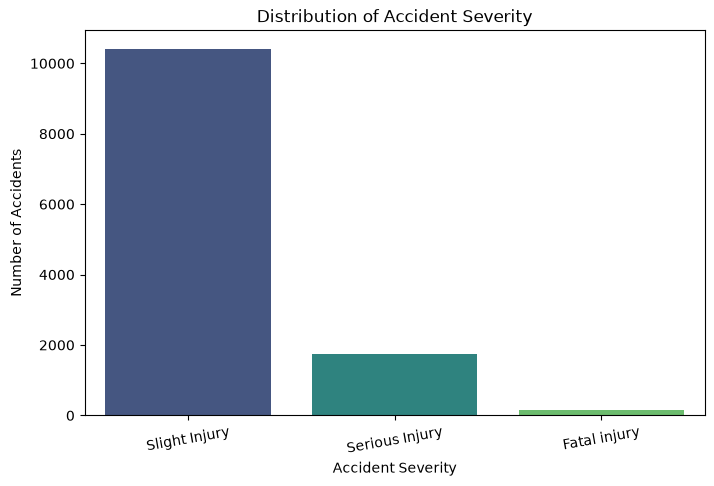

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(8,5))

# Plot
sns.countplot(
    x='Accident_severity',
    data=df,
    palette='viridis'
)

# Add title and labels
plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")

# Rotate x-axis labels if needed
plt.xticks(rotation=10)

# Show plot
plt.show()

Observation 1: 1. The Slight injury class has the highest number of accidents, indicating that most road accidents result in minor injuries.
               2. The dataset is imbalanced, as the number of records in each severity class is not evenly distributed.

C:\Users\hp\AppData\Local\Temp\ipykernel_18612\560578378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


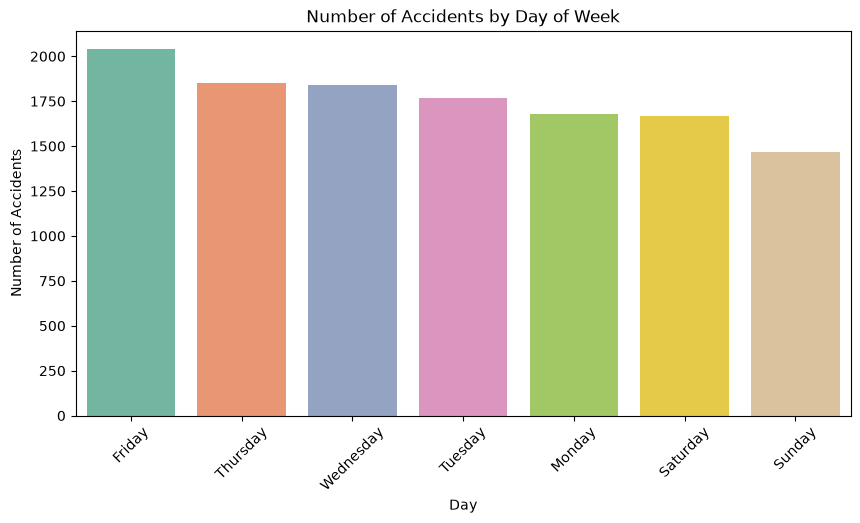

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Day_of_week',
    data=df,
    palette='Set2',
    order=df['Day_of_week'].value_counts().index
)

plt.title("Number of Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

plt.show()

Observation 2: 1. Friday recorded the highest number of accidents, indicating increased road activity and traffic on that day.
               2. Sunday had the less accidents, suggesting comparatively lower traffic volume or safer driving conditions.
               3. Weekdays generally experience a higher number of accidents due to regular commuting, work-related travel, and increased vehicle movement.
               4. Understanding these patterns can help traffic authorities plan road safety campaigns, improve traffic management, and allocate emergency response resources more effectively.

C:\Users\hp\AppData\Local\Temp\ipykernel_18612\2395783430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


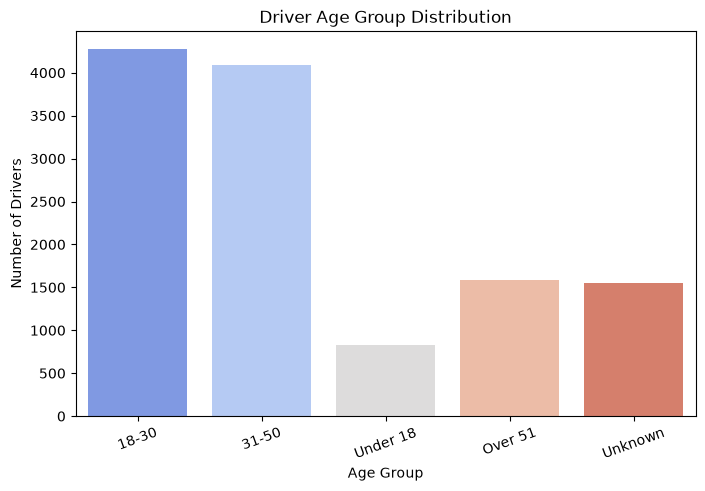

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Age_band_of_driver',
    data=df,
    palette='coolwarm'
)

plt.title("Driver Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Drivers")
plt.xticks(rotation=20)

plt.show()

Observation 3: 1. The distribution suggests that the majority of accident-involved drivers belong to the 18–50 age range, which may be because this age group constitutes the largest proportion of active drivers and spends more time on the road.
               2. The 31–50 age group is the second most common, with a count close to that of the 18–30 group.
               3. The Over 51 and Unknown age groups have a moderate number of accident records and are significantly lower than the 18–30 and 31–50 age groups.
               4. The Under 18 age group has the lowest number of drivers involved in accidents, indicating that very few accidents involve drivers below 18 years of age.

C:\Users\hp\AppData\Local\Temp\ipykernel_18612\3066764081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


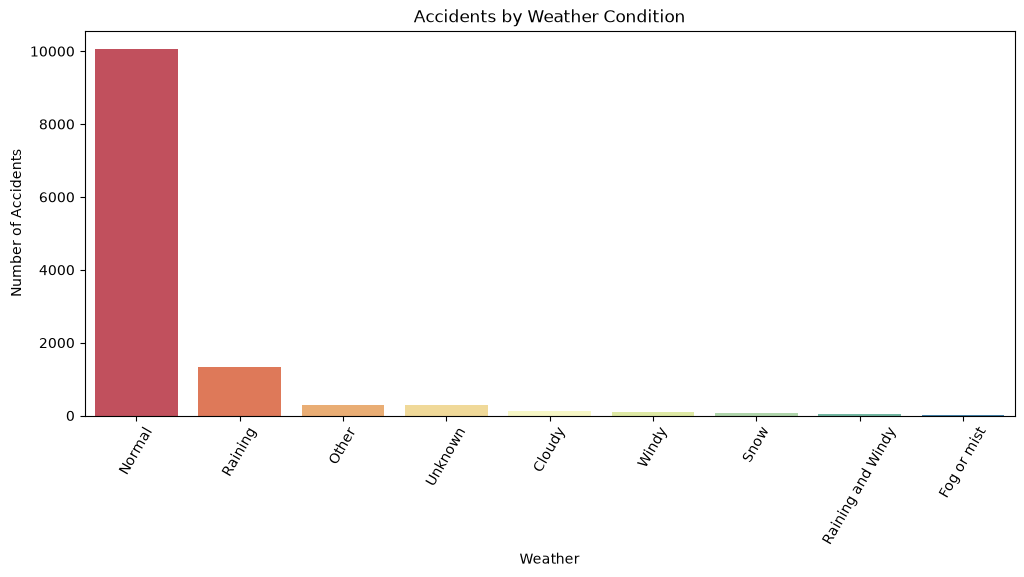

In [14]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Weather_conditions',
    data=df,
    order=df['Weather_conditions'].value_counts().index,
    palette='Spectral'
)

plt.title("Accidents by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=60)

plt.show()

Observation 4: 1. The Normal weather condition accounts for the highest number of road accidents by a large margin, indicating that most accidents occur during clear weather conditions.
               2. Raining is the second most common weather condition associated with accidents, although the number of accidents is significantly lower than in normal weather. Cloudy, Windy, Snow, Raining and Windy, and Fog or Mist contribute only a small proportion of the total accidents.
               3. The results suggest that weather alone is not the primary cause of most road accidents, as the majority occur under normal weather conditions. Although adverse weather conditions have fewer recorded accidents, they may still increase accident risk due to reduced visibility, slippery roads, or poor vehicle control.

C:\Users\hp\AppData\Local\Temp\ipykernel_18612\3175624967.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


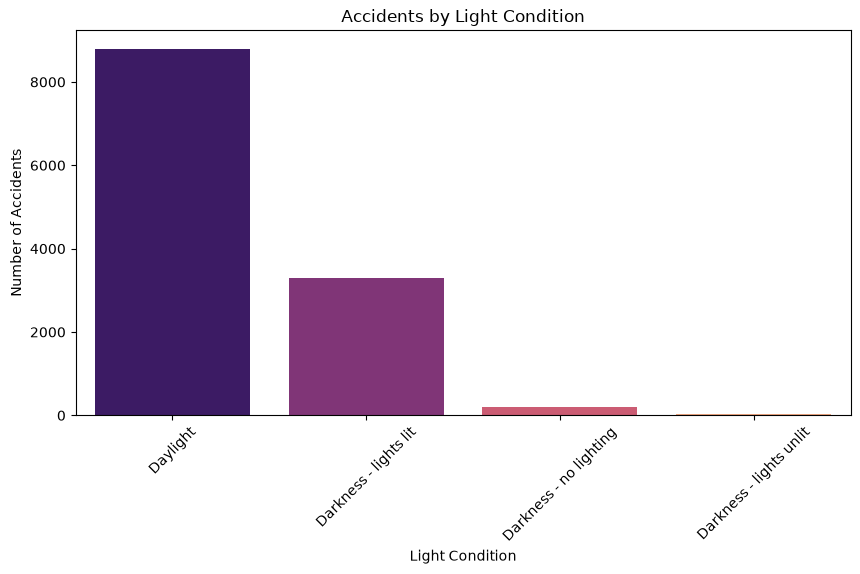

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Light_conditions',
    data=df,
    order=df['Light_conditions'].value_counts().index,
    palette='magma'
)

plt.title("Accidents by Light Condition")
plt.xlabel("Light Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

plt.show()

Observation 5:The high number of accidents during daylight is likely due to increased traffic volume, as more people travel during the day for work, education, and other daily activities.
Although accidents are fewer during dark conditions, reduced visibility at night may still contribute to higher accident severity, highlighting the importance of adequate road lighting and cautious driving.

C:\Users\hp\AppData\Local\Temp\ipykernel_18612\1916138848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


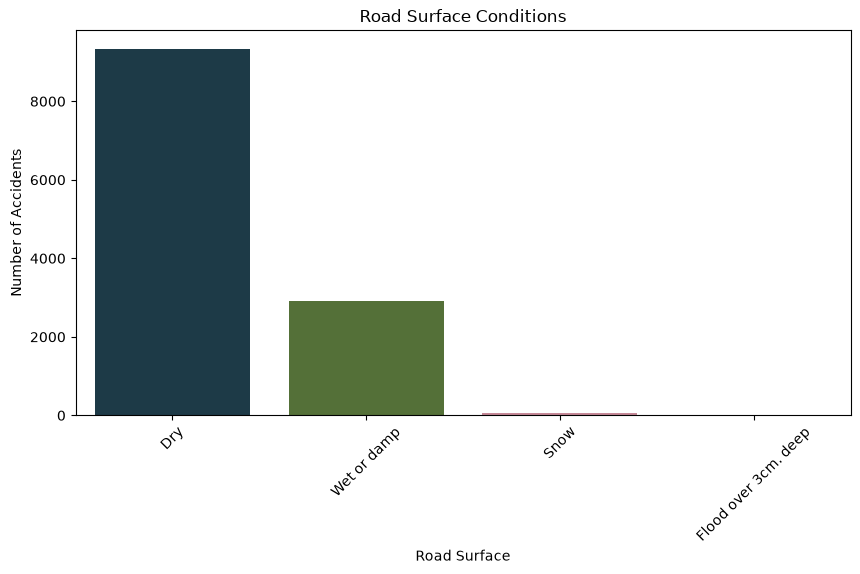

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Road_surface_conditions',
    data=df,
    order=df['Road_surface_conditions'].value_counts().index,
    palette='cubehelix'
)

plt.title("Road Surface Conditions")
plt.xlabel("Road Surface")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

plt.show()

Observation 6: The majority of road accidents occurred on Dry road surfaces, making it the most common road condition associated with accidents.Although wet or damp roads have fewer accidents than dry roads, they can increase the risk of skidding, reduced tire grip, and longer braking distances, emphasizing the need for cautious driving during rainy conditions.

C:\Users\hp\AppData\Local\Temp\ipykernel_18612\3786066411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


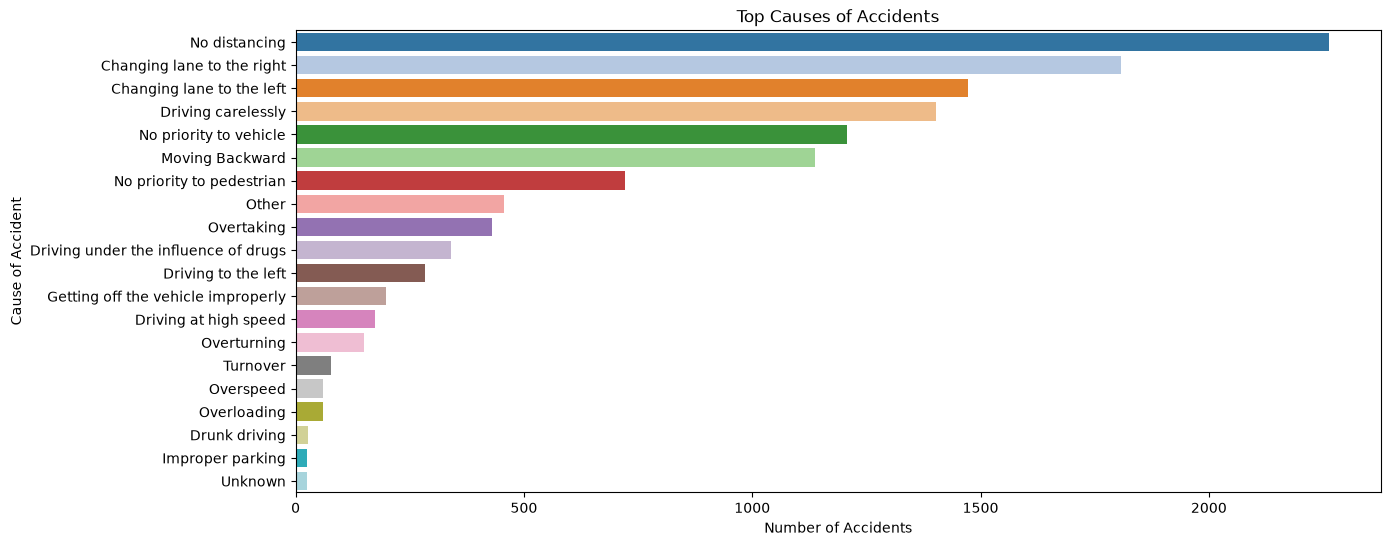

In [17]:
plt.figure(figsize=(14,6))

sns.countplot(
    y='Cause_of_accident',
    data=df,
    order=df['Cause_of_accident'].value_counts().index,
    palette='tab20'
)

plt.title("Top Causes of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Cause of Accident")

plt.show()

Observation 7: 1. No distancing is the leading cause of road accidents, indicating that maintaining a safe following distance is crucial for preventing collisions.
               2. Unsafe lane changing (both to the right and left) and careless driving are among the top contributors, showing that driver behavior plays a major role in accident occurrence.
               3. Overall, the analysis indicates that human driving behavior-highlighting the need for better driver awareness, stricter traffic law enforcement, and safe driving practices.

C:\Users\hp\AppData\Local\Temp\ipykernel_18612\3956970798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


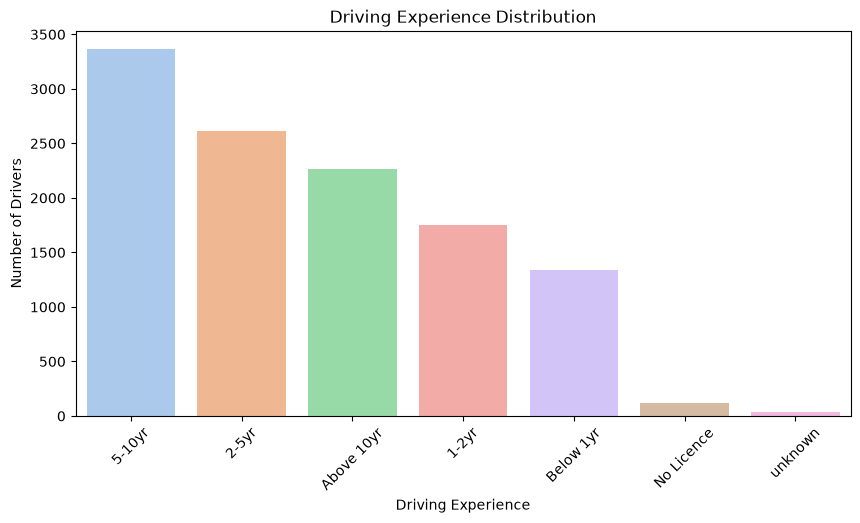

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Driving_experience',
    data=df,
    order=df['Driving_experience'].value_counts().index,
    palette='pastel'
)

plt.title("Driving Experience Distribution")
plt.xlabel("Driving Experience")
plt.ylabel("Number of Drivers")
plt.xticks(rotation=45)

plt.show()

Observation 8: 1. Drivers with 5–10 years of experience are involved in the highest number of accidents, followed by drivers with 2–5 years of experience.
               2. Drivers with more than 10 years of experience also account for a significant number of accidents, suggesting that experience alone does not eliminate accident risk.
               3. Drivers with less than 1 year and 1–2 years of experience are involved in comparatively fewer accidents than the more experienced groups.
               4. The No Licence and Unknown categories have very few records, indicating that most accidents involve licensed drivers with some driving experience.

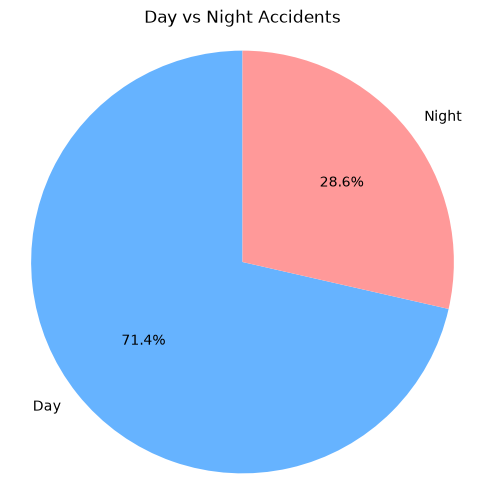

In [22]:
conds = df['Light_conditions'].fillna('Unknown').str.lower()
day_night = conds.apply(lambda x: 'Day' if 'daylight' in x else ('Night' if 'darkness' in x else 'Unknown'))

counts = day_night.value_counts()
plt.figure(figsize=(6,6))
counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff', '#ff9999', '#c2c2f0'],
    labels=counts.index
)
plt.title('Day vs Night Accidents')
plt.ylabel('')
plt.axis('equal')
plt.show()

Observation 9: 1. The higher proportion of daytime accidents is likely due to increased traffic volume, as most people travel during the day for work, education, and daily activities.
               2. Although fewer accidents occur at night, night-time driving can still pose higher risks because of reduced visibility, driver fatigue, and impaired judgment.
               3. The analysis suggests that traffic density and driver behavior have a greater influence on accident occurrence than the time of day alone.

# Phase 5: Feature Engineering

In [23]:
# Check missing values
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [25]:
df = df.drop(columns=["Service_year_of_vehicle"])

In [ ]:
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [27]:
df.isnull().sum()

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian_movement            0
Cause_of_accident              0
Accident_s

In [29]:
X = df.drop("Accident_severity", axis=1)

y = df["Accident_severity"]

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in X.columns:
    if X[column].dtype == "object":
        X[column] = le.fit_transform(X[column].astype(str))

In [32]:
y = le.fit_transform(y)

In [33]:
X.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Defect_of_vehicle,...,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,No defect,...,2,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Moving Backward
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,No defect,...,2,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,No defect,...,2,Going straight,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the left
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,No defect,...,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,No defect,...,2,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (9852, 30)
Testing Features : (2464, 30)
Training Labels : (9852,)
Testing Labels  : (2464,)


In [36]:
X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)